In [17]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import torch

List of interfaces possible to connect the gradients of the circuits with classical ML libraries

In [18]:
print(qml.math.SUPPORTED_INTERFACE_NAMES)

# numpy, torch, JAX, tensorflow

[<Interface.AUTOGRAD: 'autograd'>, <Interface.NUMPY: 'numpy'>, <Interface.TORCH: 'torch'>, <Interface.JAX: 'jax'>, <Interface.JAX_JIT: 'jax-jit'>, <Interface.TF: 'tf'>, <Interface.TF_AUTOGRAPH: 'tf-autograph'>, <Interface.AUTO: 'auto'>]


In [19]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev, interface="torch") # here we define it, Autograd by default (numpy)
def torch_circuit(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

theta_angle = torch.tensor(0.0, requires_grad=True)
result = torch_circuit(theta_angle)
print(result)

tensor(1., dtype=torch.float64, grad_fn=<DotBackward0>)


# Training Loop

Now try that θ angle qubit change from ∣0⟩ to ∣1⟩

With ∣1⟩ state, spected value of measuring in Z is -1

In [20]:
@qml.qnode(dev)
def training_circuit(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# Cost function
def cost(theta):
    return training_circuit(theta)

# Initialize at random (near 0)
theta = np.array(0.1, requires_grad=True)

# Classical Optimizer (Gradient Descent)
opt = qml.GradientDescentOptimizer(stepsize=0.4)

# Training Loop
steps = 50
print(f"Initial value of θ: {theta:.5f} | Initial cost: {cost(theta):.4f}\n")

for i in range(steps):
    # Optimizer calculates gradient and updates the parameter
    theta, actual_cost = opt.step_and_cost(cost, theta)
    
    if (i + 1) % 5 == 0:
        print(f"Step {i + 1:2d} | New parameter θ: {theta:.5f} | Cost: {actual_cost:.4f}")

print(f"Optimum angle is near Pi (3.14159): {theta:.5f}")

Initial value of θ: 0.10000 | Initial cost: 0.9950

Step  5 | New parameter θ: 0.53051 | Cost: 0.9281
Step 10 | New parameter θ: 2.12152 | Cost: -0.1549
Step 15 | New parameter θ: 3.04631 | Cost: -0.9875
Step 20 | New parameter θ: 3.13417 | Cost: -0.9999
Step 25 | New parameter θ: 3.14102 | Cost: -1.0000
Step 30 | New parameter θ: 3.14155 | Cost: -1.0000
Step 35 | New parameter θ: 3.14159 | Cost: -1.0000
Step 40 | New parameter θ: 3.14159 | Cost: -1.0000
Step 45 | New parameter θ: 3.14159 | Cost: -1.0000
Step 50 | New parameter θ: 3.14159 | Cost: -1.0000
Optimum angle is near Pi (3.14159): 3.14159


# Calculate gradient

2 ways:

- Backpropagation (diff_method="backprop"): 
    - Use the interface of the node
    - Very fast
    - Consume a lot of RAM
    - Can't use it with Quantum Hardware

- Parameter Shift (diff_method="parameter-shift"): 
    - Slow in simulators (100 parameters = 200 runs in the circuit)
    - Can use it with Quantum Hardware

​
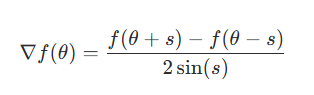

Usually s = π/2

In [21]:
# Demonstration of Parameter-Shift Rule (by hand)

@qml.qnode(dev, diff_method="parameter-shift")
def circuit_ps(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# Starting point
theta_prueba = np.array(0.75, requires_grad=True)

# Automatic Gradient (Pennylane)
automatic_gradient = qml.grad(circuit_ps)(theta_prueba)

# Gradient by hand using Parameter-Shift
shift = np.pi / 2  # s = pi/2 (then denominator 2*sin(pi/2) = 2)

# Evaluate forward (theta + shift)
evaluacion_adelante = circuit_ps(theta_prueba + shift)
# Evaluate backward (theta - shift)
evaluacion_atras = circuit_ps(theta_prueba - shift)

# Use the formula
manual_gradient = (evaluacion_adelante - evaluacion_atras) / 2.0

print(f"Gradient using qml.grad: \t{automatic_gradient:.6f}")
print(f"Gradient by hand: \t{manual_gradient:.6f}")
print("They are exactly equal")

Gradient using qml.grad: 	-0.681639
Gradient by hand: 	-0.681639
They are exactly equal
